In [ ]:
# impoting libraries 
import pandas as pd
import matplotlib.pyplot as plt 
from datasets import load_dataset
import ast

# loading dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [72]:
df_skills = df.explode('job_skills')

In [77]:
skills_count = df_skills.groupby(['job_title_short','job_skills']).size()
# same thing
# df_skills.pivot_table(index = ['job_title_short','job_skills'], aggfunc = 'size')

# converting in to dataframe
df_skills_count = skills_count.reset_index(name = 'skills_count')

# sorting
df_skills_count.sort_values('skills_count', ascending = False, inplace=True)

In [93]:
job_title = 'Data Engineer'
nskill = 15


df_skills_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(nskill)
df_skills_final

,job_title_short,job_skills,skills_count
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
686,Data Engineer,aws,62049
687,Data Engineer,azure,60674
860,Data Engineer,spark,53656
763,Data Engineer,java,35559
770,Data Engineer,kafka,29073
755,Data Engineer,hadoop,28815
848,Data Engineer,scala,28716
712,Data Engineer,databricks,27477


Text(0, 0.5, '')

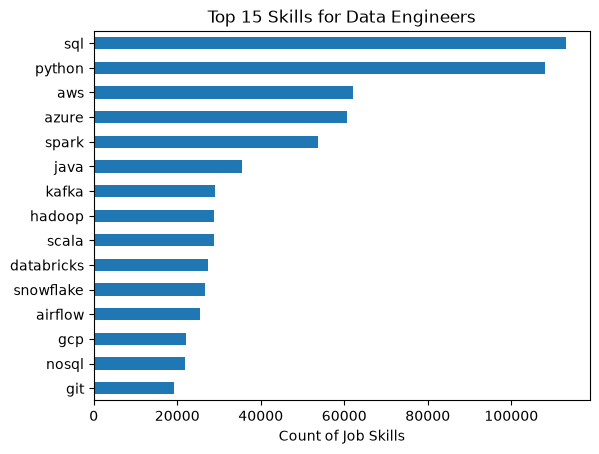

In [95]:
df_skills_final.plot(kind="barh", x = 'job_skills', y='skills_count')
plt.gca().invert_yaxis()
plt.title(f'Top {nskill} Skills for {job_title}s')
plt.legend().set_visible(False)
plt.xlabel('Count of Job Skills')
plt.ylabel('')